<a href="https://colab.research.google.com/github/Peeyusj/week19_huggingface/blob/main/week19_huggingface.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from transformers import pipeline


In [2]:
generator = pipeline('text-generation', model='gpt2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [3]:
classifier = pipeline('sentiment-analysis')
output = classifier('I absolutely loved this movie!')
print(output)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9998785257339478}]


In [4]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained('gpt2')

In [5]:
text = "Hello, I am learning Hugging Face!"
tokens = tokenizer(text)
print(tokens)

{'input_ids': [15496, 11, 314, 716, 4673, 12905, 2667, 15399, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [6]:
for id in tokens['input_ids']:
    print(id, '->', tokenizer.decode([id]))

15496 -> Hello
11 -> ,
314 ->  I
716 ->  am
4673 ->  learning
12905 ->  Hug
2667 -> ging
15399 ->  Face
0 -> !


In [7]:
from transformers import AutoModelForCausalLM

model = AutoModelForCausalLM.from_pretrained('gpt2')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
import torch

input_ids = tokenizer("The meaning of life is", return_tensors='pt')
print(input_ids)

{'input_ids': tensor([[ 464, 3616,  286, 1204,  318]]), 'attention_mask': tensor([[1, 1, 1, 1, 1]])}


In [9]:
with torch.no_grad():
    outputs = model(**input_ids)

print(type(outputs))
print(outputs.logits.shape)

<class 'transformers.modeling_outputs.CausalLMOutputWithCrossAttentions'>
torch.Size([1, 5, 50257])


In [10]:
next_token_logits = outputs.logits[0, -1, :]
print(next_token_logits.shape)

torch.Size([50257])


In [11]:
next_token_id = next_token_logits.argmax()
print(next_token_id)

tensor(407)


In [12]:
print(tokenizer.decode([407]))

 not


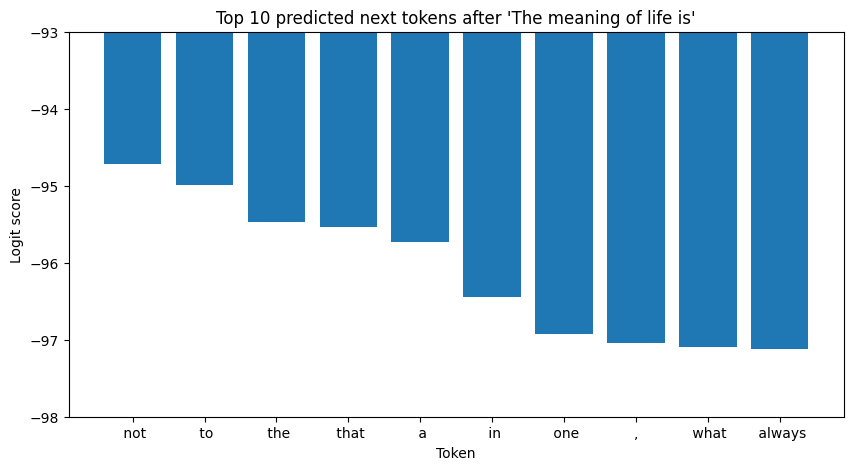

In [16]:
import matplotlib.pyplot as plt

# get top 10 predicted next tokens
top10 = next_token_logits.topk(10)

labels = [tokenizer.decode([i]) for i in top10.indices]
values = top10.values.tolist()

plt.figure(figsize=(10, 5))
plt.bar(labels, values)
plt.title("Top 10 predicted next tokens after 'The meaning of life is'")
plt.xlabel("Token")
plt.ylabel("Logit score")
plt.ylim(-98, -93)
plt.show()


In [14]:
for label, value in zip(labels, values):
    print(f"{label}: {value:.2f}")

 not: -94.72
 to: -94.99
 the: -95.47
 that: -95.53
 a: -95.73
 in: -96.45
 one: -96.93
,: -97.04
 what: -97.09
 always: -97.11


In [17]:
import torch.nn.functional as F

probs = F.softmax(next_token_logits, dim=-1)
top10_probs = probs.topk(10)

labels = [tokenizer.decode([i]) for i in top10_probs.indices]
values = top10_probs.values.tolist()

for label, value in zip(labels, values):
    print(f"{label}: {value:.4f}")

 not: 0.1088
 to: 0.0829
 the: 0.0513
 that: 0.0482
 a: 0.0396
 in: 0.0193
 one: 0.0119
,: 0.0106
 what: 0.0101
 always: 0.0099


In [18]:
sum(values)

0.39276121836155653

In [20]:
input_ids = tokenizer("The meaning of life is", return_tensors='pt')

output = model.generate(
    input_ids['input_ids'],
    max_new_tokens=20
)

print(tokenizer.decode(output[0]))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


The meaning of life is not the same as the meaning of death.

The meaning of life is not the same as


In [21]:
print(output)
print(output.shape)

tensor([[ 464, 3616,  286, 1204,  318,  407,  262,  976,  355,  262, 3616,  286,
         1918,   13,  198,  198,  464, 3616,  286, 1204,  318,  407,  262,  976,
          355]])
torch.Size([1, 25])


In [24]:
print(tokenizer.decode([198]))

In [25]:
for id in [1918, 13, 198, 198]:
    print(id, '->', repr(tokenizer.decode([id])))

1918 -> ' death'
13 -> '.'
198 -> '\n'
198 -> '\n'
